# 1. Chuyển đổi mask thành polygon 

In [4]:
from pathlib import Path
import cv2

# Thư mục chứa toàn bộ mask
MASK_DIR = Path("/Users/mac/MeterReadAI/data/WaterMeters/masks")

# Thư mục lưu polygon
OUTPUT_DIR = Path("/Users/mac/MeterReadAI/data/WaterMeters/labels")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for mask_path in MASK_DIR.glob("*.jpg"):

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        print("Không đọc được:", mask_path.name)
        continue

    h, w = mask.shape

    # Chuyển mask thành nhị phân
    _, binary = cv2.threshold(
        mask, 0, 255, cv2.THRESH_BINARY
    )

    # Tìm contour
    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    lines = []

    for contour in contours:

        # Bỏ vùng quá nhỏ
        if cv2.contourArea(contour) < 10:
            continue

        # Giảm số điểm polygon
        epsilon = 0.002 * cv2.arcLength(contour, True)
        polygon = cv2.approxPolyDP(
            contour, epsilon, True
        )

        if len(polygon) < 3:
            continue

        points = []

        for p in polygon:
            x, y = p[0]

            # Normalize về 0-1
            points.append(x / w)
            points.append(y / h)

        # class_id = 0
        lines.append(
            "0 " + " ".join(
                f"{p:.6f}" for p in points
            )
        )

    # Lưu .txt
    output_path = OUTPUT_DIR / f"{mask_path.stem}.txt"

    with open(output_path, "w") as f:
        f.write("\n".join(lines))

print("Hoàn tất chuyển đổi mask thành polygon.")

Hoàn tất chuyển đổi mask thành polygon.


# 2. Visualize polygon với ảnh

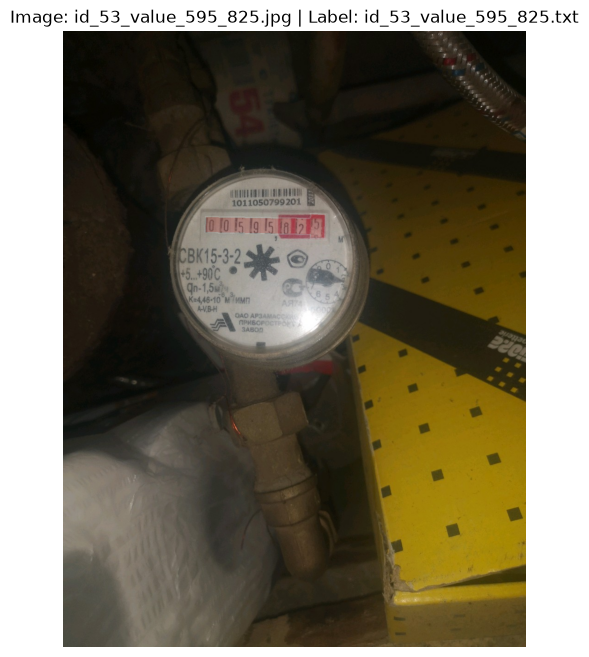

Tổng polygon: 1
Ảnh: /Users/mac/MeterReadAI/data/WaterMeters/images/id_53_value_595_825.jpg
Label: /Users/mac/MeterReadAI/data/WaterMeters/labels/id_53_value_595_825.txt


In [6]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_dir = Path("/Users/mac/MeterReadAI/data/WaterMeters/images")
label_dir = Path("/Users/mac/MeterReadAI/data/WaterMeters/labels")

image_path = next(image_dir.glob("*.jpg"), None)
label_path = label_dir / f"{image_path.stem}.txt"
img_bgr = cv2.imread(str(image_path))


img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

all_polygons = []
with open(label_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        values = np.array([float(v) for v in parts[1:]], dtype=np.float32)
        if values.size % 2 != 0 or values.size < 6:
            continue
        pts = values.reshape(-1, 2)
        pts[:, 0] = pts[:, 0] * w
        pts[:, 1] = pts[:, 1] * h
        all_polygons.append(pts.astype(np.int32))

overlay = img_rgb.copy()
for pts in all_polygons:
    cv2.fillPoly(overlay, [pts], color=(255, 0, 0))
    cv2.polylines(overlay, [pts], isClosed=True, color=(255, 255, 255), thickness=2)

vis = cv2.addWeighted(img_rgb, 0.85, overlay, 0.15, 0)

plt.figure(figsize=(12, 8))
plt.imshow(vis)
plt.title(f"Image: {image_path.name} | Label: {label_path.name}")
plt.axis("off")
plt.show()

print(f"Tổng polygon: {len(all_polygons)}")
print(f"Ảnh: {image_path}")
print(f"Label: {label_path}")


# 3. Phân chia train thành train và validation

In [7]:
from pathlib import Path
import shutil
import random

ROOT = Path("/Users/mac/MeterReadAI/data/water_meters")

IMAGE_DIR = ROOT / "images"
LABEL_DIR = ROOT / "labels"

OUTPUT = ROOT / "yolo"

# Tạo thư mục
for split in ["train", "val", "test"]:
    (OUTPUT / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT / "labels" / split).mkdir(parents=True, exist_ok=True)


# =========================
# 1. LẤY IMAGE + LABEL
# =========================

pairs = []

for image_path in IMAGE_DIR.iterdir():

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
        continue

    label_path = LABEL_DIR / f"{image_path.stem}.txt"

    if not label_path.exists():
        print("⚠️ Thiếu label:", image_path.name)
        continue

    pairs.append((image_path, label_path))


print("Tổng số cặp:", len(pairs))


# =========================
# 2. SHUFFLE
# =========================

random.seed(42)
random.shuffle(pairs)


# =========================
# 3. CHIA 80 / 10 / 10
# =========================

total = len(pairs)

train_end = int(total * 0.8)
val_end = int(total * 0.9)

splits = {
    "train": pairs[:train_end],
    "val": pairs[train_end:val_end],
    "test": pairs[val_end:]
}


# =========================
# 4. COPY
# =========================

for split, split_pairs in splits.items():

    for image_path, label_path in split_pairs:

        shutil.copy2(
            image_path,
            OUTPUT / "images" / split / image_path.name
        )

        shutil.copy2(
            label_path,
            OUTPUT / "labels" / split / label_path.name
        )


# =========================
# 5. KẾT QUẢ
# =========================


for split, split_pairs in splits.items():
    print(f"{split:5}: {len(split_pairs)} ảnh")

Tổng số cặp: 1244
train: 995 ảnh
val  : 124 ảnh
test : 125 ảnh
